# Optimisation de LightGBM et du seuil métier

Ce notebook optimise progressivement LightGBM, puis choisit un seuil de décision qui minimise le coût métier `10 × FN + FP`.

## Chargement et séparation des données

In [2]:
# ---------- Bibliothèques ----------
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

# ---------- Configuration des données ----------
DATA_PATH = Path("../data/processed/application_train_final_encoded.csv")
ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
RANDOM_STATE = 42

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required_columns = {ID_COLUMN, TARGET_COLUMN}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colonnes obligatoires absentes : {sorted(missing_columns)}")

X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = df[TARGET_COLUMN]

# 20 % sont réservés à l'évaluation finale.
X_development, X_final, y_development, y_final = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Les 80 % restants sont séparés en 60 % entraînement et 20 % seuil.
X_train, X_threshold, y_train, y_threshold = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_development,
)

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Entraînement : {len(X_train):,} lignes")
print(f"Sélection du seuil : {len(X_threshold):,} lignes")
print(f"Évaluation finale : {len(X_final):,} lignes")
print(f"Poids de la classe 1 : {SCALE_POS_WEIGHT:.2f}")

Entraînement : 184,506 lignes
Sélection du seuil : 61,502 lignes
Évaluation finale : 61,502 lignes
Poids de la classe 1 : 11.39


## Preprocessing et coût métier

L'imputation médiane est apprise uniquement pendant l'entraînement. Le coût métier pénalise un faux négatif dix fois plus qu'un faux positif.

In [ ]:
# ---------- Pipeline LightGBM ----------
def create_lightgbm_pipeline(model_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", LGBMClassifier(**model_params)),
    ])


# ---------- Coût métier ----------
FN_COST = 10
FP_COST = 1
THRESHOLDS = [value / 100 for value in range(10, 91, 5)]

"""Cette fonction calcule le coût métier associé aux prédictions du modèle.
Elle récupère le nombre de faux négatifs et de faux positifs grâce à la matrice de confusion, 
puis applique la formule 10 × FN + 1 × FP. 
Plus ce coût est faible, plus les décisions prises par le modèle sont intéressantes du point de vue métier."""

def business_cost(y_true, y_pred):
    _, fp, fn, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return FN_COST * fn + FP_COST * fp


def find_best_business_threshold(y_true, probabilities):
    best_threshold = None
    best_cost = float("inf")

    for threshold in THRESHOLDS:
        predictions = (probabilities >= threshold).astype(int)
        cost = business_cost(y_true, predictions)

        if cost < best_cost:
            best_threshold = threshold
            best_cost = cost

    return best_threshold, best_cost


def minimum_business_cost_scorer(estimator, X_validation, y_validation):
    probabilities = estimator.predict_proba(X_validation)[:, 1]
    _, best_cost = find_best_business_threshold(y_validation, probabilities)
    return -best_cost


def business_recall_scorer(estimator, X_validation, y_validation):
    probabilities = estimator.predict_proba(X_validation)[:, 1]
    best_threshold, _ = find_best_business_threshold(
        y_validation, probabilities
    )
    predictions = (probabilities >= best_threshold).astype(int)
    return recall_score(y_validation, predictions, pos_label=1)


# ---------- Métriques d'évaluation ----------
def evaluate_predictions(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1_score": f1_score(y_true, y_pred, pos_label=1),
        "fn": int(fn),
        "fp": int(fp),
        "business_cost": int(FN_COST * fn + FP_COST * fp),
    }

## Optimisation des hyperparamètres

Pour chaque combinaison et chaque fold, le scorer teste les seuils de 0,10 à 0,90 et conserve le coût minimal. La moyenne de ces coûts sélectionne les hyperparamètres. ROC AUC et recall restent des contrôles sans influencer le classement.

In [4]:
# ---------- Modèle utilisé pendant la recherche ----------
GRID_MODEL_PARAMS = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbosity": -1,
}

PARAM_GRID = {
    "classifier__n_estimators": [100, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__num_leaves": [15, 31],
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "business_cost": minimum_business_cost_scorer,
    "roc_auc": "roc_auc",
    "recall": business_recall_scorer,
}

grid_search = GridSearchCV(
    estimator=create_lightgbm_pipeline(GRID_MODEL_PARAMS),
    param_grid=PARAM_GRID,
    scoring=SCORING,
    cv=CV,
    n_jobs=-1,
    refit=False,
    verbose=1,
)

grid_search.fit(X_train, y_train)

grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results["cv_business_cost_mean"] = -grid_results["mean_test_business_cost"]
grid_results["cv_business_cost_std"] = grid_results["std_test_business_cost"]
grid_results["cv_roc_auc_mean"] = grid_results["mean_test_roc_auc"]
grid_results["cv_recall_mean"] = grid_results["mean_test_recall"]
grid_results = grid_results.sort_values("rank_test_business_cost")

best_grid_row = grid_results.iloc[0]
BEST_GRID_PARAMS = best_grid_row["params"]
BEST_CV_BUSINESS_COST = float(best_grid_row["cv_business_cost_mean"])

display(grid_results[[
    "params", "cv_business_cost_mean", "cv_business_cost_std",
    "cv_roc_auc_mean", "cv_recall_mean", "rank_test_business_cost",
]])
print("Meilleurs paramètres :", BEST_GRID_PARAMS)
print(f"Meilleur coût métier CV : {BEST_CV_BUSINESS_COST:,.0f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,params,cv_business_cost_mean,cv_business_cost_std,cv_roc_auc_mean,cv_recall_mean,rank_test_business_cost
2,"{'classifier__learning_rate': 0.05, 'classifie...",18549.0,280.239897,0.776501,0.656101,1
3,"{'classifier__learning_rate': 0.05, 'classifie...",18611.6,231.708955,0.775885,0.642878,2
6,"{'classifier__learning_rate': 0.1, 'classifier...",18634.4,259.595532,0.773279,0.682959,3
5,"{'classifier__learning_rate': 0.1, 'classifier...",18674.0,317.257624,0.775038,0.671546,4
4,"{'classifier__learning_rate': 0.1, 'classifier...",18721.8,282.734787,0.774125,0.672416,5
1,"{'classifier__learning_rate': 0.05, 'classifie...",18850.8,310.292378,0.772385,0.652543,6
7,"{'classifier__learning_rate': 0.1, 'classifier...",18919.8,234.530510,0.769941,0.678394,7
0,"{'classifier__learning_rate': 0.05, 'classifie...",18979.4,375.450982,0.768899,0.641062,8


Meilleurs paramètres : {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 300, 'classifier__num_leaves': 15}
Meilleur coût métier CV : 18,549


## Suivi MLflow des combinaisons

Chaque combinaison produit un seul run contenant les résultats moyens des cinq folds. Aucun run individuel n'est créé pour un fold.

In [5]:
# ---------- Un run MLflow par combinaison ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

for run_number, (_, result) in enumerate(grid_results.iterrows(), start=1):
    model_params = {
        name.replace("classifier__", ""): value
        for name, value in result["params"].items()
    }

    with mlflow.start_run(
        run_name=f"lightgbm_search_rank_{run_number:02d}"
    ):
        mlflow.set_tag("stage", "hyperparameter_search")
        mlflow.log_param("business_cost_rank", run_number)
        mlflow.log_params(model_params)
        mlflow.log_metrics({
            "cv_business_cost_mean": result["cv_business_cost_mean"],
            "cv_business_cost_std": result["cv_business_cost_std"],
            "cv_roc_auc_mean": result["cv_roc_auc_mean"],
            "cv_recall_mean": result["cv_recall_mean"],
        })

## Entraînement du meilleur modèle

In [6]:
# ---------- Reconstruction des meilleurs paramètres ----------
best_model_params = {
    name.replace("classifier__", ""): value
    for name, value in BEST_GRID_PARAMS.items()
}
OPTIMIZED_PARAMS = {
    **GRID_MODEL_PARAMS,
    **best_model_params,
    "n_jobs": -1,
}

optimized_model = create_lightgbm_pipeline(OPTIMIZED_PARAMS)
optimized_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](319,)","['NAME_CONTRACT_TYPE','FLAG_OWN_CAR','FLAG_OWN_REALTY',..., 'PREV_POS_REMAINING_INSTALLMENTS_SUM','PREV_CC_BALANCE_LATEST_SUM', 'PREV_HAS_HISTORY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,319
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_va

## Optimisation du seuil métier

Le seuil est choisi uniquement sur l'ensemble prévu à cet effet. L'ensemble final reste totalement à l'écart de cette décision.

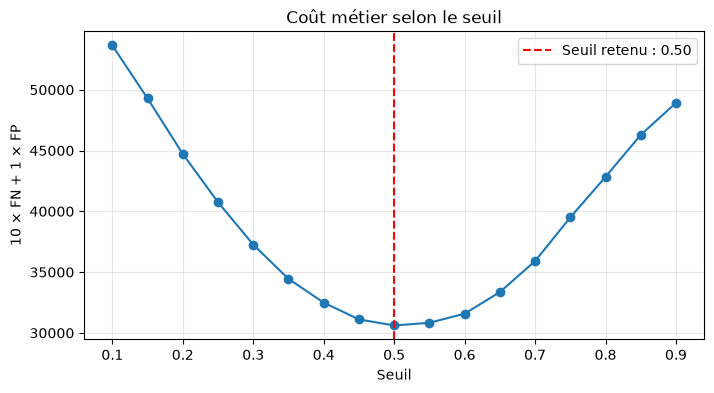

Seuil retenu : 0.50
Coût sur l'ensemble de sélection : 30,607


In [7]:
# ---------- Recherche du seuil au coût minimal ----------
threshold_scores = optimized_model.predict_proba(X_threshold)[:, 1]
threshold_results = []

for threshold in THRESHOLDS:
    predictions = (threshold_scores >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "business_cost": business_cost(y_threshold, predictions),
    })

threshold_results = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results.loc[
    threshold_results["business_cost"].idxmin()
]
BEST_THRESHOLD = float(best_threshold_row["threshold"])
MIN_THRESHOLD_COST = int(best_threshold_row["business_cost"])

cost_figure, cost_axis = plt.subplots(figsize=(8, 4))
cost_axis.plot(threshold_results["threshold"], threshold_results["business_cost"], marker="o")
cost_axis.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Seuil retenu : {BEST_THRESHOLD:.2f}")
cost_axis.set(
    title="Coût métier selon le seuil",
    xlabel="Seuil",
    ylabel=f"{FN_COST} × FN + {FP_COST} × FP",
)
cost_axis.legend()
cost_axis.grid(alpha=0.3)
plt.show()

print(f"Seuil retenu : {BEST_THRESHOLD:.2f}")
print(f"Coût sur l'ensemble de sélection : {MIN_THRESHOLD_COST:,}")

## Évaluation finale

Le modèle initial et le modèle optimisé sont comparés sur les mêmes clients jamais utilisés par GridSearchCV ni par la sélection du seuil.

In [8]:
# ---------- Modèle LightGBM initial équilibré ----------
BASELINE_PARAMS = {
    "boosting_type": "gbdt",
    "n_estimators": 100,
    "learning_rate": 0.1,
    "num_leaves": 31,
    "max_depth": -1,
    "objective": "binary",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}
baseline_model = create_lightgbm_pipeline(BASELINE_PARAMS)
baseline_model.fit(X_train, y_train)

# ---------- Prédictions sur l'ensemble final ----------
baseline_scores = baseline_model.predict_proba(X_final)[:, 1]
optimized_scores = optimized_model.predict_proba(X_final)[:, 1]

baseline_predictions = (baseline_scores >= 0.5).astype(int)
optimized_default_predictions = (optimized_scores >= 0.5).astype(int)
optimized_business_predictions = (optimized_scores >= BEST_THRESHOLD).astype(int)

final_results = pd.DataFrame({
    "baseline_threshold_0.5": evaluate_predictions(
        y_final, baseline_predictions, baseline_scores
    ),
    "optimized_threshold_0.5": evaluate_predictions(
        y_final, optimized_default_predictions, optimized_scores
    ),
    "optimized_business_threshold": evaluate_predictions(
        y_final, optimized_business_predictions, optimized_scores
    ),
}).T
display(final_results)

,roc_auc,recall,f1_score,fn,fp,business_cost
baseline_threshold_0.5,0.773230,0.676939,0.282817,1604.0,15442.0,31482.0
optimized_threshold_0.5,0.774705,0.685801,0.283490,1560.0,15652.0,31252.0
optimized_business_threshold,0.774705,0.685801,0.283490,1560.0,15652.0,31252.0


## Tracking MLflow et conclusion

Cette dernière cellule enregistre uniquement les résultats déjà calculés. Elle ne relance ni GridSearchCV ni l'entraînement.

In [9]:
# ---------- Tracking MLflow manuel ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

final_metrics = final_results.loc["optimized_business_threshold"]

with mlflow.start_run(run_name="lightgbm_optimized_final"):
    mlflow.set_tag("stage", "final_evaluation")
    mlflow.set_tag("description", "LightGBM optimisé avec seuil métier")
    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("cv_folds", CV.get_n_splits())
    mlflow.log_param("cost_fn", FN_COST)
    mlflow.log_param("cost_fp", FP_COST)
    mlflow.log_param("best_threshold", BEST_THRESHOLD)

    for name, value in best_model_params.items():
        mlflow.log_param(f"best_{name}", value)

    mlflow.log_metric("threshold_validation_min_cost", MIN_THRESHOLD_COST)
    mlflow.log_metrics(final_metrics.to_dict())

    mlflow.log_figure(cost_figure, "business_cost_by_threshold.png")

print("Run MLflow enregistré : lightgbm_optimized_final")

Run MLflow enregistré : lightgbm_optimized_final


### Lecture des résultats

Le modèle final doit réduire le coût métier et les faux négatifs sans provoquer une hausse disproportionnée des faux positifs. Le ROC AUC vérifie la qualité globale du classement, tandis que le recall et le F1-score complètent l'interprétation du seuil retenu.